In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from scipy import stats
import utils
import seaborn as sns
import pingouin as pg
import matplotlib.cm as cm

import statsmodels.stats.power as smp
from statsmodels.stats.anova import AnovaRM
from tqdm import tqdm

# reload utils
import importlib
importlib.reload(utils)


from natsort import index_natsorted

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.family'] = 'Calibri'

path_figs = "./Figs/"

seq_length = 7 #Length of sequences

windowSizes = [1, 2, 3, 7]

fingers = ['1', '2', '3', '4', '5'] #mapping of fingers to numbers

iti = 3000   #Inter trial interval
hand = 2 #left or right hand

# total_sub_num = 10
sub_nums = [1,2,3, 4, 5, 6, 7, 8, 9, 10, 11]

num_trained_seq = 1

total_sub_num = 20
num_sessions = 4
num_blocks_per_session = 4

num_baseline_blocks = 1
num_trials_per_block = 40

percentile_low = 45; percentile_high = 80; percentile_low_super = 10; #percentiles for categorizing ETs




In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker

def set_figure_style(scale="1col"):
    """
    Set figure styling based on publication constraints.
    
    Parameters:
        scale (str): Scale of the figure, choose from "1col", "1.5col", "2col".
                     - "1col" for 8.5cm
                     - "1.5col" for 11.6cm
                     - "2col" for 17.6cm
    """
    # Define width options in cm
    widths = {"1col": 7.62, "1.5col": 11.6, "2col": 16.5}
    
    if scale not in widths:
        raise ValueError("Invalid scale. Choose from '1col', '1.5col', or '2col'.")
    
    # Convert width from cm to inches (1 cm = 0.393701 inches)
    width_in = widths[scale] * 0.393701
    
    # Set figure size (width, height)
    # Assuming height proportional to width (Golden Ratio)
    golden_ratio = (5**0.5 - 1) / 2
    rcParams["figure.figsize"] = (width_in, width_in * golden_ratio)
    
    # Set font sizes
    rcParams["font.size"] = 10  # General font size
    # rcParams["font.size"] = 20  # General font size
    rcParams["axes.titlesize"] = 12  # Figure title
    # rcParams["axes.titlesize"] = 26  # Figure title
    rcParams["axes.labelsize"] = 9  # Axis main label
    # rcParams["axes.labelsize"] = 22  # Axis main label
    rcParams["xtick.labelsize"] = 7  # Tick labels
    # rcParams["xtick.labelsize"] = 16  # Tick labels
    rcParams["ytick.labelsize"] = 7
    # rcParams["ytick.labelsize"] = 16
    rcParams["legend.fontsize"] = 8  # Legend entries
    # rcParams["legend.fontsize"] = 20  # Legend entries
    rcParams["figure.titleweight"] = "bold"
    
    # Set stroke width
    rcParams["axes.linewidth"] = 0.75
    # rcParams["axes.linewidth"] = 1.5

    # rcParams["lines.linewidth"] = 3
    
    rcParams["xtick.major.width"] = 0.75
    # rcParams["xtick.major.width"] = 1.5
    rcParams["ytick.major.width"] = 0.75
    # rcParams["ytick.major.width"] = 1.5

    
    # Subpanel lettering size
    rcParams["text.usetex"] = False  # Set to True if using LaTeX
    rcParams["axes.formatter.use_mathtext"] = True  # Math text for scientific notation

def add_subpanel_label(ax, label, fontsize=20, position=(-0.1, 1.05)):
    """
    Add a subpanel label (e.g., 'a', 'b') to a subplot.
    
    Parameters:
        ax (Axes): Matplotlib Axes object.
        label (str): The label text.
        fontsize (int): Font size for the label.
        position (tuple): Position of the label in axes coordinates.
    """
    ax.text(position[0], position[1], label, transform=ax.transAxes, 
            fontsize=fontsize, fontweight="bold", va="top", ha="left")

###
set_figure_style(scale="1col")

sns.set_palette("colorblind")


In [3]:
subjs = pd.read_csv(utils.path_misc+'subjs.csv', sep = '\t')

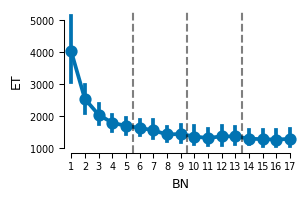

In [4]:
subjs_correct = utils.remove_error_trials(subjs) ###Removing error trials
subjs_grouped = subjs_correct.groupby(['SubNum', 'BN']).agg({
    'ET': 'median'
}).reset_index()
sns.pointplot(data = subjs_grouped, x = 'BN', y = 'ET')
for day_change in [4.5, 8.5, 12.5]:
    plt.axvline(day_change, color = 'k', linestyle = '--', alpha = 0.5)
sns.despine(trim = True)


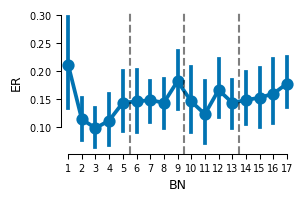

In [5]:
error_data = subjs.copy()
error_data['count'] = 1
error_data = error_data.groupby(['SubNum', 'BN']).agg({
    'count': 'sum',
    'isError': 'sum'
}).reset_index()

error_data['ER'] = error_data['isError'] / error_data['count']


sns.pointplot(data = error_data, x = 'BN', y = 'ER')
for day_change in [4.5, 8.5, 12.5]:
    plt.axvline(day_change, color = 'k', linestyle = '--', alpha = 0.5)
sns.despine(trim = True)

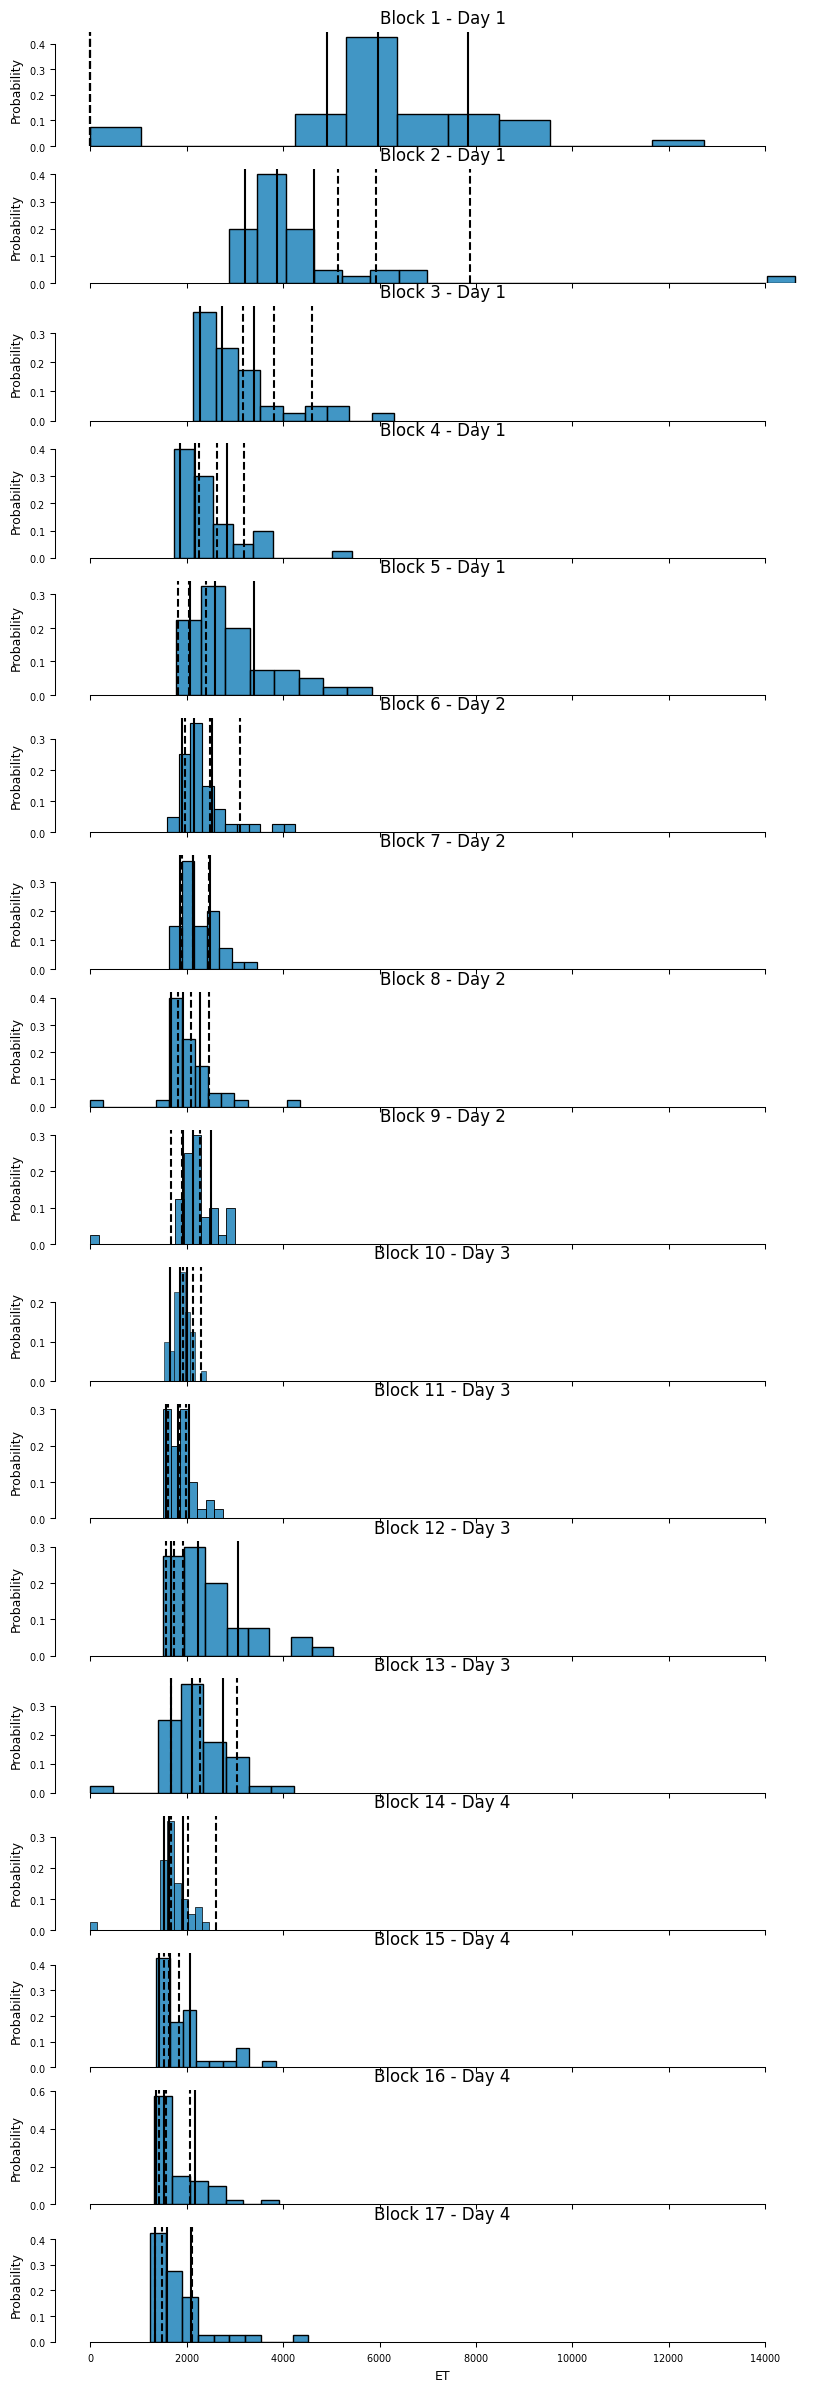

In [6]:
fig, axs = plt.subplots(len(subjs['BN'].unique()),1, figsize=(10, 30), sharex=True)
selected_sub = subjs[subjs['SubNum'] == 6] ###Selecting one subject
day_changes = [5.5, 9.5, 13.5, 17.5] #Day change points

# selected_sub = utils.remove_error_trials(selected_sub) ###Removing error trials for the selected subject
for bn, block_data in selected_sub.groupby('BN'):
    sns.histplot(data = block_data, x = 'ET', ax = axs[bn-1], stat = 'probability')
    axs[bn-1].axvline(block_data['estimatedPercentileHigh'].values[0], linestyle = '--', color = 'black')
    axs[bn-1].axvline(block_data['estimatedPercentileLow'].values[0], linestyle = '--', color = 'black')
    axs[bn-1].axvline(block_data['estimatedPercentileLowSuper'].values[0],linestyle = '--', color = 'black')

    axs[bn-1].axvline(np.percentile(block_data['ET'], percentile_low_super), linestyle = '-', color = 'black')
    axs[bn-1].axvline(np.percentile(block_data['ET'], percentile_low), linestyle = '-', color = 'black')
    axs[bn-1].axvline(np.percentile(block_data['ET'], percentile_high), linestyle = '-', color = 'black')


    
    for day, day_change in enumerate(day_changes):
        if bn < day_change:
            break


    

    axs[bn-1].set_title(f'Block {bn} - Day {day+1}')

sns.despine(trim = True)

# Force Analysis

In [11]:
subjs = pd.read_csv(utils.path_misc+'subjs.csv', sep = '\t')

# exclude first block 
subjs = subjs[subjs['BN'] > 1]
rank_df = pd.DataFrame(index = subjs.index)
for subnum, data in subjs.groupby('SubNum'):
    data = data.sort_values(by = ['BN', 'TN'])
    data['N'] = data.groupby(['BN', 'TN']).ngroup() + 1
    rank_df.loc[data.index, 'N'] = data['N'].astype('int')
        

subjs['N'] = rank_df['N'].astype('int')
subjs = subjs[subjs['isCross'] == 0]

# adding day column to subjs
day1_blocks =list(range(2, num_blocks_per_session + 2))  # Blocks 2 to 5
day2_blocks = list(range(num_blocks_per_session + 2, num_blocks_per_session * 2 + 2))  # Blocks 6 to 9
day3_blocks = list(range(num_blocks_per_session * 2 + 2, num_blocks_per_session * 3 + 2))  # Blocks 10 to 13
day4_blocks = list(range(num_blocks_per_session * 3 + 2, num_blocks_per_session * 4 + 2))  # Blocks 14 to 17

subjs['day'] = 0
subjs.loc[subjs['BN'].isin(day1_blocks), 'day'] = 1
subjs.loc[subjs['BN'].isin(day2_blocks), 'day'] = 2
subjs.loc[subjs['BN'].isin(day3_blocks), 'day'] = 3
subjs.loc[subjs['BN'].isin(day4_blocks), 'day'] = 4

aligned_cut_force = pd.read_csv(utils.path_misc+'aligned_cut_force.csv', sep = '\t')
aligned_cut_force = aligned_cut_force[aligned_cut_force['isCross'] == 0]


### plot original and normalized forces at different trials

In [6]:
def plot_force(force_data, subnum, n):
    """
    Plot the force data for a given subject and trial number.
    
    Parameters:
        subnum (int): Subject number.
        n (int): Trial number.
    """
    sub_data = force_data[(force_data['SubNum'] == subnum) & (force_data['N'] == n)]

    if sub_data.empty:
        print(f"No data available for SubNum {subnum} and N {n}.")
        return
    
    fig, ax = plt.subplots(figsize=(5, 2))
    
    sns.lineplot(data=sub_data, x='time', y='Force_Value', hue='Force_Number', ax=ax)
    
    ax.set_title(f'Subject {subnum}, Trial {n}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Force (N)')
    
    plt.legend(title='Finger')
    plt.show()

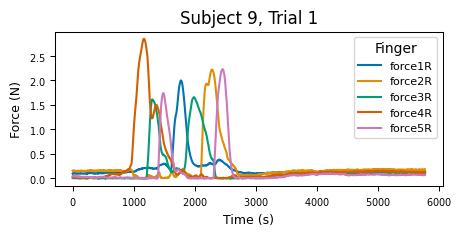

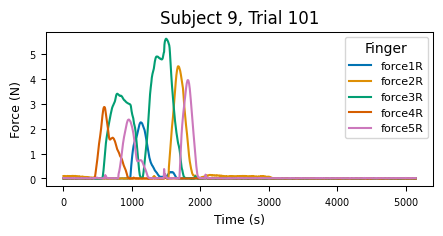

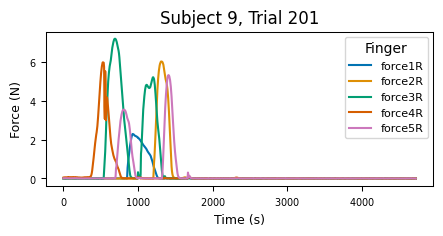

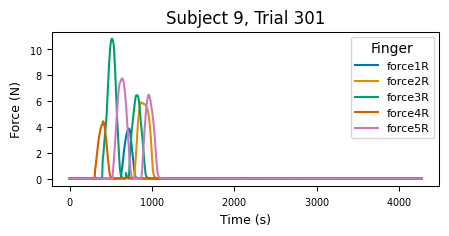

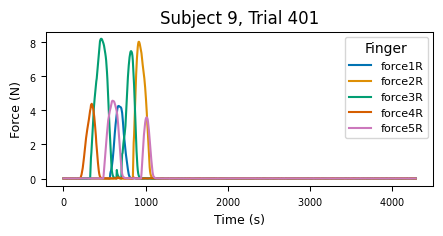

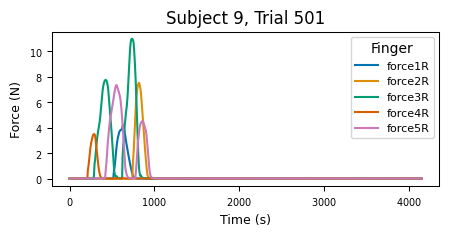

In [7]:
subjs_forces = pd.read_csv(utils.path_misc+'subjs_force_train.csv', sep = '\t')
subnum = 9
trial_gap = 100
for i in range(1, 600, trial_gap):
    plot_force(subjs_forces, subnum, i)

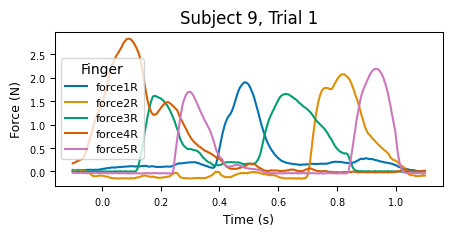

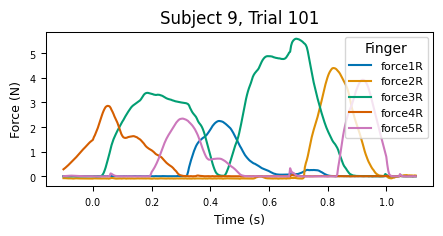

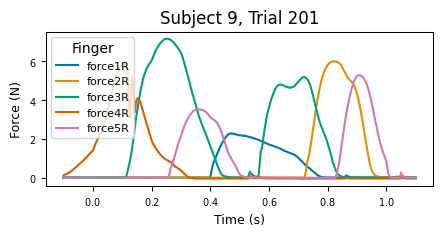

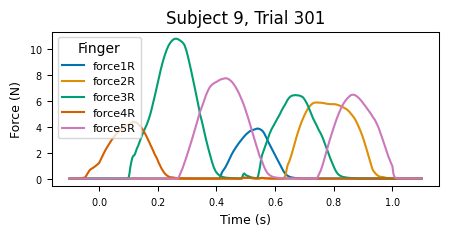

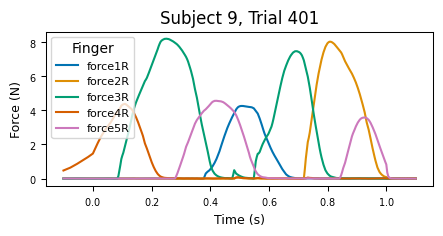

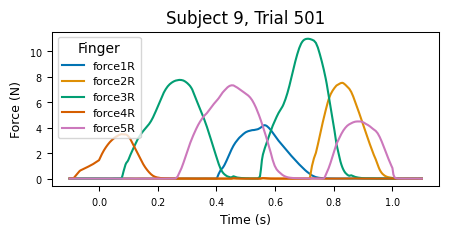

In [138]:
subnum = 9
trial_gap = 100
for i in range(1, 600, trial_gap):
    plot_force(aligned_cut_force, subnum, i)

In [12]:
def plot_force_grouped(force_data, subnum, bn):
    """
    Plot the force data for a given subject and block number.
    
    Parameters:
        subnum (int): Subject number.
        bh (int): block number.
    """
    sub_data = force_data[(force_data['SubNum'] == subnum) & (force_data['BN'] == bn)]

    if sub_data.empty:
        print(f"No data available for SubNum {subnum} and BN {bn}.")
        return
    
    fig, ax = plt.subplots(figsize=(5, 2))
    
    sns.lineplot(data=sub_data, x='time', y='Force_Value', hue='Force_Number', ax=ax)
    
    ax.set_title(f'Subject {subnum}, BN {bn}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Force (N)')
    
    plt.legend(title='Finger')
    plt.show()

In [13]:
def plot_force_grouped(force_data, subnum, day):
    """
    Plot the force data for a given subject and block number.
    
    Parameters:
        subnum (int): Subject number.
        day (int): day number.
    """
    sub_data = force_data[(force_data['SubNum'] == subnum) & (force_data['day'] == day)]

    if sub_data.empty:
        print(f"No data available for SubNum {subnum} and day {day}.")
        return
    
    fig, ax = plt.subplots(figsize=(5, 2))
    
    sns.lineplot(data=sub_data, x='time', y='Force_Value', hue='Force_Number', ax=ax)
    
    ax.set_title(f'Subject {subnum}, day {day}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Force (N)')
    
    plt.legend(title='Finger')
    plt.savefig(f'Force_Sub{subnum}_Day{day}.pdf', dpi=300, bbox_inches='tight')
    plt.show()

In [14]:
aligned_cut_force

,state,time,BN,TN,SubNum,isTrain,isCross,crossTime,points,zone,isError,RT,ET,Force_Number,Force_Value,N
0,3.0,-0.100334,2,1,1,1,0,0,3,2,0,865,3025,force1R,0.143511,1
1,3.0,-0.096990,2,1,1,1,0,0,3,2,0,865,3025,force1R,0.157839,1
2,3.0,-0.093645,2,1,1,1,0,0,3,2,0,865,3025,force1R,0.172883,1
3,3.0,-0.090301,2,1,1,1,0,0,3,2,0,865,3025,force1R,0.185659,1
4,3.0,-0.086957,2,1,1,1,0,0,3,2,0,865,3025,force1R,0.197230,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12670345,4.0,1.086957,17,40,11,1,0,0,1,2,0,335,1245,force5R,-0.054752,640
12670346,4.0,1.090301,17,40,11,1,0,0,1,2,0,335,1245,force5R,-0.056655,640
12670347,4.0,1.093645,17,40,11,1,0,0,1,2,0,335,1245,force5R,-0.056244,640
12670348,4.0,1.096990,17,40,11,1,0,0,1,2,0,335,1245,force5R,-0.051829,640


In [22]:
aligned_cut_force['day'] = 0
aligned_cut_force.loc[aligned_cut_force['BN'].isin(day1_blocks), 'day'] = 1
aligned_cut_force.loc[aligned_cut_force['BN'].isin(day2_blocks), 'day'] = 2
aligned_cut_force.loc[aligned_cut_force['BN'].isin(day3_blocks), 'day'] = 3
aligned_cut_force.loc[aligned_cut_force['BN'].isin(day4_blocks), 'day'] = 4

subjs_forces['day'] = 0
subjs_forces.loc[subjs_forces['BN'].isin(day1_blocks), 'day'] = 1
subjs_forces.loc[subjs_forces['BN'].isin(day2_blocks), 'day'] = 2
subjs_forces.loc[subjs_forces['BN'].isin(day3_blocks), 'day'] = 3
subjs_forces.loc[subjs_forces['BN'].isin(day4_blocks), 'day'] = 4

In [23]:
# grouped_aligned_cut_force = aligned_cut_force[aligned_cut_force['isError'] != 1].groupby(['time', 'BN', 'SubNum', 'Force_Number']).agg({
#     'Force_Value': 'median'
# }).reset_index()

grouped_aligned_cut_force = aligned_cut_force[aligned_cut_force['isError'] != 1].groupby(['time', 'day', 'SubNum', 'Force_Number']).agg({
    'Force_Value': 'mean'
}).reset_index()

grouped_forces = subjs_forces[ subjs_forces['isError'] != 1].groupby(['time', 'day', 'SubNum', 'Force_Number']).agg({
    'Force_Value': 'mean'
}).reset_index()

In [17]:
grouped_aligned_cut_force

,time,day,SubNum,Force_Number,Force_Value
0,-0.100334,1,1,force1R,0.487577
1,-0.100334,1,1,force2R,-0.000943
2,-0.100334,1,1,force3R,0.000141
3,-0.100334,1,1,force4R,-0.004324
4,-0.100334,1,1,force5R,-0.002466
...,...,...,...,...,...
79195,1.100334,4,11,force1R,-0.001108
79196,1.100334,4,11,force2R,0.003092
79197,1.100334,4,11,force3R,-0.015810
79198,1.100334,4,11,force4R,-0.084719


In [25]:
# for block in range(1, num_blocks_per_session * num_sessions + 1):
#     plot_force_grouped(grouped_aligned_cut_force, subnum=5, bn=block)

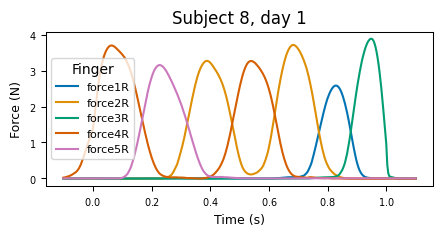

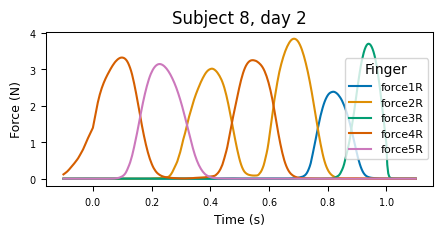

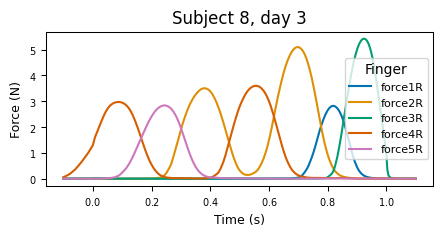

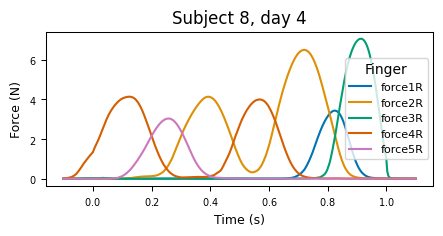

In [28]:
for day in range(1, num_sessions + 1):
    plot_force_grouped(grouped_aligned_cut_force, subnum=8, day=day)

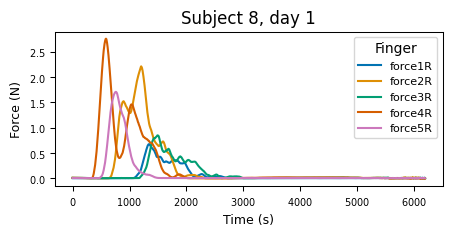

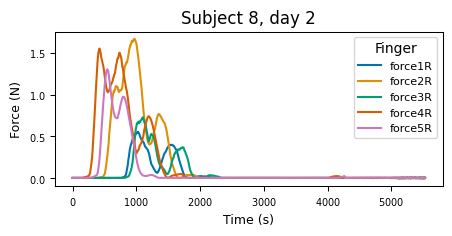

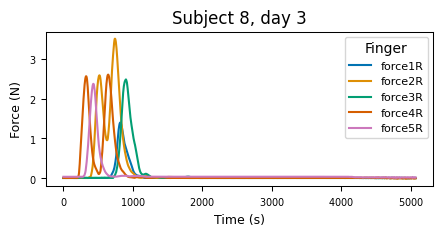

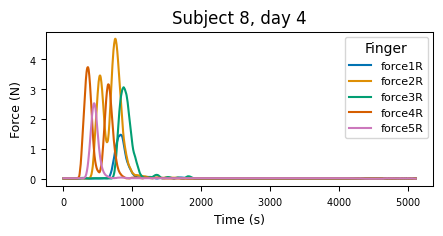

In [27]:
for day in range(1, num_sessions + 1):
    plot_force_grouped(grouped_forces, subnum=8, day=day)

In [7]:
forces_wide = aligned_cut_force.pivot_table(index=['SubNum', 'BN', 'TN', 'points', 'zone', 'N', 'ET'], columns=['Force_Number', 'time'], values = 'Force_Value').reset_index()
# convert MultiIndex columns to single level
forces_wide.columns = [''.join(map(str, col)).strip() for col in forces_wide.columns.values]
force_cols = [col for col in forces_wide.columns if col.startswith('force')]
new_names = {old: f'force_{i+1}' for i, old in enumerate(force_cols)}
forces_wide.rename(columns=new_names, inplace=True)

# create a force_vector column that is an np array of concatenated forces columns
forces_wide['force_vector'] = forces_wide[[col for col in forces_wide.columns if col.startswith('force_')]].apply(lambda x: np.array(x), axis=1)

forces_wide['day'] = 0
forces_wide.loc[forces_wide['BN'].isin(day1_blocks), 'day'] = 1
forces_wide.loc[forces_wide['BN'].isin(day2_blocks), 'day'] = 2
forces_wide.loc[forces_wide['BN'].isin(day3_blocks), 'day'] = 3
forces_wide.loc[forces_wide['BN'].isin(day4_blocks), 'day'] = 4


# adding day change column to the forces_wide dataframe
forces_wide['day_change'] = 0
forces_wide.loc[forces_wide['day'] != forces_wide['day'].shift(1), 'day_change'] = 1

# adding block change column to the forces_wide dataframe
forces_wide['block_change'] = 0
forces_wide.loc[forces_wide['BN'] != forces_wide['BN'].shift(1), 'block_change'] = 1


# change zone mapping from [0,1,2,3,4] to [0,4,3,2,1]
forces_wide['zone'] = forces_wide['zone'].map({0:0, 1:4, 2:3, 3:2, 4:1})


In [140]:
# exclude first four blocks
# forces_wide = forces_wide[forces_wide['BN'] > 4]

# Force Dynamic Over Learning

In [13]:
forces_wide['force_vector'].iloc[0]

array([0.14351137, 0.15783913, 0.17288261, ..., 0.0512    , 0.0569291 ,
       0.05453445])

In [147]:
forces_wide.columns

Index(['SubNum', 'BN', 'TN', 'points', 'zone', 'N', 'ET', 'force_1', 'force_2',
       'force_3',
       ...
       'force_1795', 'force_1796', 'force_1797', 'force_1798', 'force_1799',
       'force_1800', 'force_vector', 'day', 'day_change', 'block_change'],
      dtype='object', length=1811)

In [9]:
# calculate distance of forces based on their trial distance for each subject
distances = []

forces_wide_correct = forces_wide[forces_wide['points'] != -1]

for subind, subdata in tqdm(forces_wide_correct.groupby('SubNum')):
    # build 2D array of force_vectors 
    X = np.vstack(subdata['force_vector'].to_numpy())
    trials = subdata['N'].to_numpy()
    n = len(subdata)

    #Upper triangular indices for distance calculation
    i, j = np.triu_indices(n, k=1)

    # Calculate pairwise distances
    force_dist = np.linalg.norm(X[i] - X[j], axis=1)
    trial_dist = np.abs(trials[i] - trials[j])

    distances.append(pd.DataFrame({
        'SubNum': subind,
        'Trial1': trials[i],
        'Trial2': trials[j],
        'Force_Distance': force_dist,
        'Trial_Distance': trial_dist
    }))

# Concatenate all distances into a single DataFrame
distances_df = pd.concat(distances, ignore_index=True)


 45%|████▌     | 5/11 [00:06<00:08,  1.37s/it]


KeyboardInterrupt: 

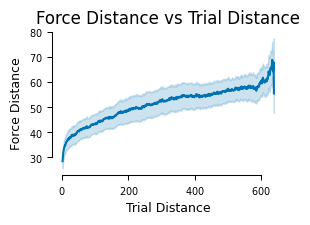

In [149]:
# plt.figure(figsize=(20, 6))

grouped_distances = distances_df.groupby(['SubNum', 'Trial_Distance']).agg({'Force_Distance': 'median'}).reset_index()

sns.lineplot(data=grouped_distances, x='Trial_Distance', y='Force_Distance', errorbar = 'se')

plt.title('Force Distance vs Trial Distance')
plt.xlabel('Trial Distance')
plt.ylabel('Force Distance')

sns.despine(trim=True)
plt.savefig(path_figs + 'force_distance_vs_trial_distance.pdf', bbox_inches='tight', dpi=300)


TtestResult(statistic=-4.077574440446515, pvalue=0.0022229994114766876, df=10)

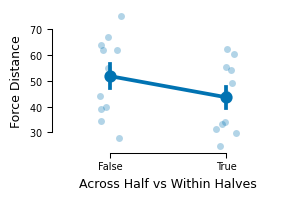

In [169]:
# seperate first half(trial number <= 640/2) and second half (trial number > 640/2)
distances_df['is_within'] = (distances_df['Trial2'] <= 640/2) | (distances_df['Trial1'] > 640/2)

grouped_distances = distances_df.groupby(['SubNum', 'is_within']).agg({'Force_Distance': 'median'}).reset_index()

sns.stripplot(data=grouped_distances, x='is_within', y='Force_Distance', alpha = 0.3, legend=False)
sns.pointplot(data=grouped_distances, x='is_within', y='Force_Distance', errorbar = 'se')
plt.xlabel('Across Half vs Within Halves')
plt.ylabel('Force Distance')
sns.despine(trim=True)
plt.savefig(path_figs + 'force_distance_across_halves.pdf', bbox_inches='tight', dpi=300)

stats.ttest_rel(grouped_distances[grouped_distances['is_within'] == True]['Force_Distance'], grouped_distances[grouped_distances['is_within'] == False]['Force_Distance'])






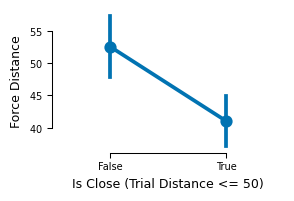

In [235]:
distances_df['is_close'] = distances_df['Trial_Distance'] <= 50

grouped_distances = distances_df.groupby(['SubNum', 'is_close']).agg({'Force_Distance': 'median'}).reset_index()

sns.pointplot(data=grouped_distances, x='is_close', y='Force_Distance', errorbar='se')
plt.xlabel('Is Close (Trial Distance <= 50)')
plt.ylabel('Force Distance')

import scipy.stats
scipy.stats.ttest_rel(grouped_distances[grouped_distances['is_close'] == True]['Force_Distance'],
                     grouped_distances[grouped_distances['is_close'] == False]['Force_Distance'])

sns.despine(trim=True)


In [43]:
# calculate distance of forces based on their trial distance for each subject
distances = []

forces_wide_correct = forces_wide[forces_wide['points'] != -1]

for subind, subdata in tqdm(forces_wide_correct.groupby('SubNum')):
    for day, day_data in subdata.groupby('day'):
        # build 2D array of force_vectors 
        X = np.vstack(day_data['force_vector'].to_numpy())
        trials = day_data['N'].to_numpy()
        n = len(day_data)

        #Upper triangular indices for distance calculation
        i, j = np.triu_indices(n, k=1)

        # Calculate pairwise distances
        force_dist = np.linalg.norm(X[i] - X[j], axis=1)
        trial_dist = np.abs(trials[i] - trials[j])

        # Calculate ET differences
        ETs = day_data['ET'].to_numpy()
        et_dist = np.abs(ETs[i] - ETs[j])

        distances.append(pd.DataFrame({
            'SubNum': subind,
            'Trial1': trials[i],
            'Trial2': trials[j],
            'Force_Distance': force_dist,
            'Trial_Distance': trial_dist,
            'ET_Distance': et_dist,
            'day': day
        }))

# Concatenate all distances into a single DataFrame
distances_df = pd.concat(distances, ignore_index=True)


100%|██████████| 11/11 [00:02<00:00,  4.60it/s]


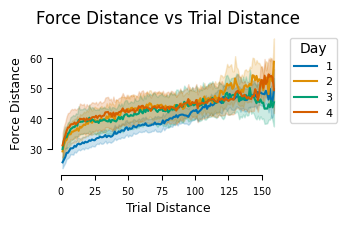

In [60]:
# plt.figure(figsize=(20, 6))

grouped_distances = distances_df.groupby(['SubNum', 'Trial_Distance', 'day']).agg({'Force_Distance': 'median'}).reset_index()

sns.lineplot(data=grouped_distances, x='Trial_Distance', y='Force_Distance', hue = 'day', errorbar = 'se', palette='colorblind')

plt.title('Force Distance vs Trial Distance')
plt.xlabel('Trial Distance')
plt.ylabel('Force Distance')

sns.despine(trim=True)
plt.legend(title='Day', loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig(path_figs + 'force_distance_vs_trial_distance_by_day.pdf', bbox_inches='tight', dpi=300)

In [99]:
# calculate distance of forces based on their trial distance for each subject
distances = []

forces_wide_correct = forces_wide[forces_wide['points'] != -1]

for subind, subdata in tqdm(forces_wide_correct.groupby('SubNum')):
    for day, day_data in subdata.groupby('day'):
        for block, block_data in day_data.groupby('BN'):
            block_data = block_data[block_data['points'] != -1]
            # build 2D array of force_vectors 
            X = np.vstack(block_data['force_vector'].to_numpy())
            trials = block_data['N'].to_numpy()
            n = len(block_data)

            #Upper triangular indices for distance calculation
            i, j = np.triu_indices(n, k=1)

            # Calculate pairwise distances
            force_dist = np.linalg.norm(X[i] - X[j], axis=1)
            # Calculate ET differences
            ETs = block_data['ET'].to_numpy()
            et_dist = np.abs(ETs[i] - ETs[j])
            is_pos = (ETs[i] - ETs[j]) > 0 

            distances.append(pd.DataFrame({
                'SubNum': subind,
                'Trial1': trials[i],
                'Trial2': trials[j],
                'Force_Distance': force_dist,
                'ET_Distance': et_dist,
                'is_pos': is_pos,
                'day': day
            }))

# Concatenate all distances into a single DataFrame
distances_df = pd.concat(distances, ignore_index=True)


100%|██████████| 11/11 [00:00<00:00, 15.96it/s]


In [102]:
# distances_df = distances_df[distances_df['ET_Distance'] < 3000]
distances_df = distances_df[distances_df['ET_Distance'] < 1000]

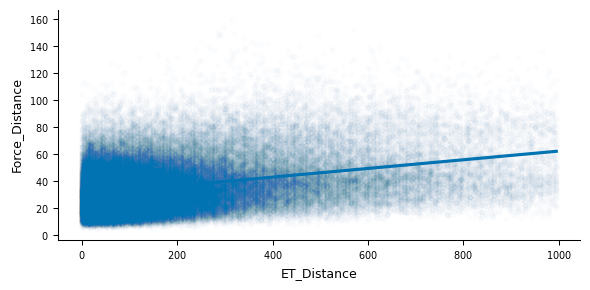

In [109]:
# sns.lmplot(data = distances_df, x = 'ET_Distance', y = 'Force_Distance', hue ='is_pos', scatter_kws={'s': 10, 'alpha': 0.3}, ci=95, height=3, aspect=2, palette = 'colorblind')
sns.lmplot(data = distances_df, x = 'ET_Distance', y = 'Force_Distance', scatter_kws={'s': 10, 'alpha': 0.01}, ci=95, height=3, aspect=2)
# sns.lmplot(data = distances_df, x = 'ET_Distance', y = 'Force_Distance', scatter_kws={'s': 10, 'alpha': 0.0}, ci=95, height=3, aspect=2)

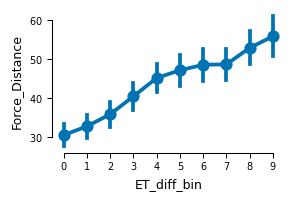

In [114]:
ET_diff_bin_size = 100
distances_df.loc[:, 'ET_diff_bin'] = distances_df['ET_Distance'] // ET_diff_bin_size
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin']).agg({'Force_Distance': 'median'}).reset_index()
# grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'is_pos']).agg({'Force_Distance': 'median'}).reset_index()
sns.pointplot(data=grouped_distances, x='ET_diff_bin', y='Force_Distance', errorbar='se')
# sns.pointplot(data=grouped_distances, x='ET_diff_bin', y='Force_Distance', errorbar='se', hue = 'is_pos')
sns.despine(trim=True)


In [119]:
np.linalg.norm(np.diff(X, axis=0), axis=1).shape

(34,)

In [144]:
# calculate distance of forces based on their trial distance for each subject
distances = []

forces_wide_correct = forces_wide[forces_wide['points'] != -1]

for subind, subdata in tqdm(forces_wide_correct.groupby('SubNum')):
    for day, day_data in subdata.groupby('day'):
        for block, block_data in day_data.groupby('BN'):
            block_data = block_data[block_data['points'] != -1]
            # build 2D array of force_vectors 
            X = np.vstack(block_data['force_vector'].to_numpy())
            force_dists = np.linalg.norm(np.diff(X, axis=0), axis=1)
            # Calculate ET differences
            ETs = block_data['ET'].to_numpy()
            et_dist = np.abs(np.diff(ETs))
            is_pos = (np.diff(ETs)) > 0

            distances.append(pd.DataFrame({
                'SubNum': subind,
                'Force_Distance': force_dists,
                'ET_Distance': et_dist,
                'is_pos': is_pos,
                'day': day
            }))

# Concatenate all distances into a single DataFrame
distances_df = pd.concat(distances, ignore_index=True)


100%|██████████| 11/11 [00:00<00:00, 70.20it/s]


In [155]:
distances_df = distances_df[distances_df['ET_Distance'] < 800]

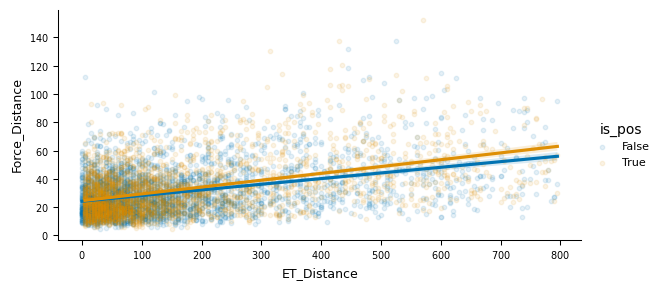

In [156]:
# sns.lmplot(data = distances_df, x = 'ET_Distance', y = 'Force_Distance', scatter_kws={'s': 10, 'alpha': 0.1}, ci=95, height=3, aspect=2)
sns.lmplot(data = distances_df, x = 'ET_Distance', y = 'Force_Distance', scatter_kws={'s': 10, 'alpha': 0.1}, ci=95, height=3, aspect=2, hue = 'is_pos', palette='colorblind')


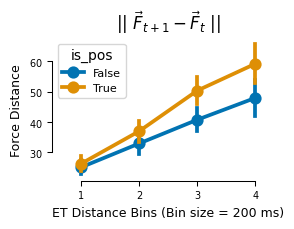

In [174]:
ET_diff_bin_size = 200
distances_df.loc[:,'ET_diff_bin'] = (distances_df['ET_Distance'] // ET_diff_bin_size) + 1
# grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin']).agg({'Force_Distance': 'median'}).reset_index()
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'is_pos']).agg({'Force_Distance': 'median'}).reset_index()
# sns.pointplot(data=grouped_distances, x='ET_diff_bin', y='Force_Distance', errorbar='se')
sns.pointplot(data=grouped_distances, x='ET_diff_bin', y='Force_Distance', errorbar='se', hue = 'is_pos')
plt.xlabel(f'ET Distance Bins (Bin size = {ET_diff_bin_size} ms)')
plt.ylabel('Force Distance')
plt.title(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')
sns.despine(trim=True)

In [177]:
grouped_distances[['ET_diff_bin', 'is_pos']].value_counts()

ET_diff_bin  is_pos
1            False     11
             True      11
2            False     11
             True      11
3            False     11
             True      11
4            False     11
             True      10
Name: count, dtype: int64

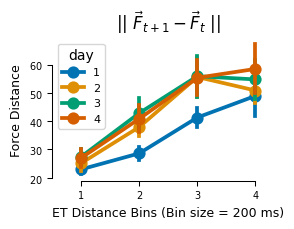

In [170]:
ET_diff_bin_size = 200
distances_df.loc[:,'ET_diff_bin'] = (distances_df['ET_Distance'] // ET_diff_bin_size) + 1
# grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin']).agg({'Force_Distance': 'median'}).reset_index()
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'day']).agg({'Force_Distance': 'median'}).reset_index()
# sns.pointplot(data=grouped_distances, x='ET_diff_bin', y='Force_Distance', errorbar='se')
sns.pointplot(data=grouped_distances, x='ET_diff_bin', y='Force_Distance', errorbar='se', hue = 'day', palette='colorblind')
plt.xlabel(f'ET Distance Bins (Bin size = {ET_diff_bin_size} ms)')
plt.ylabel('Force Distance')
plt.title(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')
sns.despine(trim=True)

In [173]:
grouped_distances[['ET_diff_bin', 'day']].value_counts()

ET_diff_bin  day
1            1      11
             2      11
             3      11
             4      11
2            1      11
             2      11
             3      11
             4      11
3            1      11
             2      11
             4      11
4            3      11
3            3      10
4            1      10
             2       8
             4       8
Name: count, dtype: int64

# Modulation of Force Variance over Learning

In [101]:
# calculate variance of forces on a moving window for each subject
window_size = 10
distances = []
for subind, subdata in forces_wide.groupby('SubNum'):
    for i in range(len(subdata) - window_size):
        window_data = subdata.iloc[i:i + window_size]
        # window_data = window_data[window_data['points'] != -1]
        # print(len(window_data))
        # compute the variance of the force vectors in the window
        force_vectors = np.array(window_data['force_vector'].tolist())
        mean_force = np.mean(force_vectors, axis=0)
        var = np.sqrt(((force_vectors - mean_force) ** 2).sum(axis = 1).mean())

        # var = stats.iqr(((force_vectors - mean_force) ** 2).sum(axis = 1))

        distances.append({
            'SubNum': subind,
            'variance': var,
            'N': window_data['N'].values[0]
        })

distances = pd.DataFrame(distances)

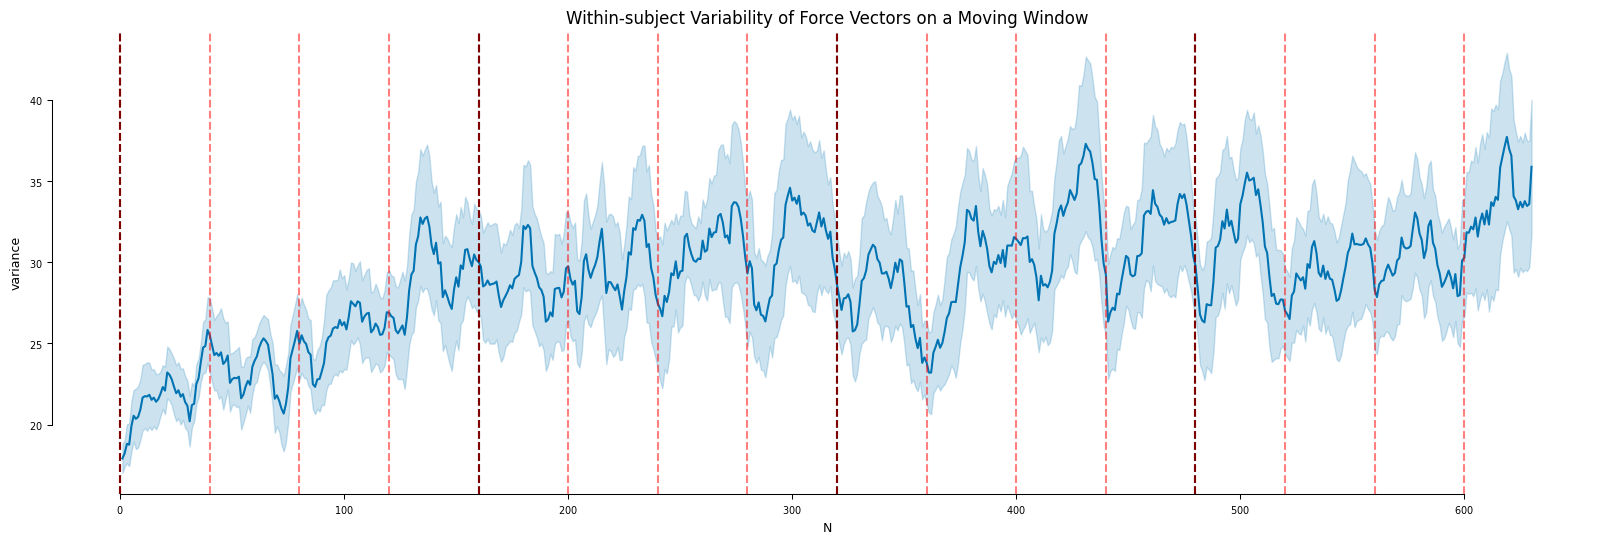

In [102]:
plt.figure(figsize=(20, 6))
# distances = distances[distances['SubNum'] == 10]
# distances = distances[~distances['SubNum'].isin([1,2])]
sns.lineplot(data=distances, x='N', y='variance', errorbar='se')

#plot day changes
day_changes = forces_wide[forces_wide['day_change'] == 1]
for n in day_changes['N'].unique():
    plt.axvline(n - 1, color='black', linestyle='--', alpha=1)


# plot block changes
block_changes = forces_wide[forces_wide['block_change'] == 1]
for n in block_changes['N'].unique():
    plt.axvline(n - 1, color='red', linestyle='--', alpha=0.5)

plt.title('Within-subject Variability of Force Vectors on a Moving Window')

sns.despine(trim=True)

In [240]:
# # calculate variance of forces on a moving window for each subject
# window_size = 10
# distances = []


# for N, ndata in forces_wide.groupby('N'):
#     force_vectors = np.array(ndata['force_vector'].tolist())
#     mean_force = np.mean(force_vectors, axis=0)
#     var = np.sqrt(((force_vectors - mean_force) ** 2).sum(axis = 1).mean())

#     distances.append({
#         'variance': var,
#         'N': N
#     })

# distances = pd.DataFrame(distances)

In [241]:
# plt.figure(figsize=(20, 6))

# sns.lineplot(data=distances, x='N', y='variance', errorbar='se')

# #plot day changes
# day_changes = forces_wide[forces_wide['day_change'] == 1]
# for n in day_changes['N'].unique():
#     plt.axvline(n - 1, color='black', linestyle='--', alpha=1)

# # plot block changes
# block_changes = forces_wide[forces_wide['block_change'] == 1]
# for n in block_changes['N'].unique():
#     plt.axvline(n - 1, color='red', linestyle='--', alpha=0.5)
    
# plt.title('Across subjects Variability of Force Vectors')
# sns.despine(trim=True)


In [125]:
# calculate variance of ETs on a moving window for each subject
window_size = 10
distances = []
for subind, subdata in forces_wide.groupby('SubNum'):
    for i in range(len(subdata) - window_size):
        window_data = subdata.iloc[i:i + window_size]

        # window_data = window_data[window_data['points'] != -1]


        # compute iqr of the ETs in the window
        # var = stats.iqr(window_data['ET'].values)

        # compute the variance of the ETs in the window
        var = np.std(window_data['ET'].values)

        distances.append({
            'SubNum': subind,
            'variance': var,
            'N': window_data['N'].values[0]
        })

distances = pd.DataFrame(distances)

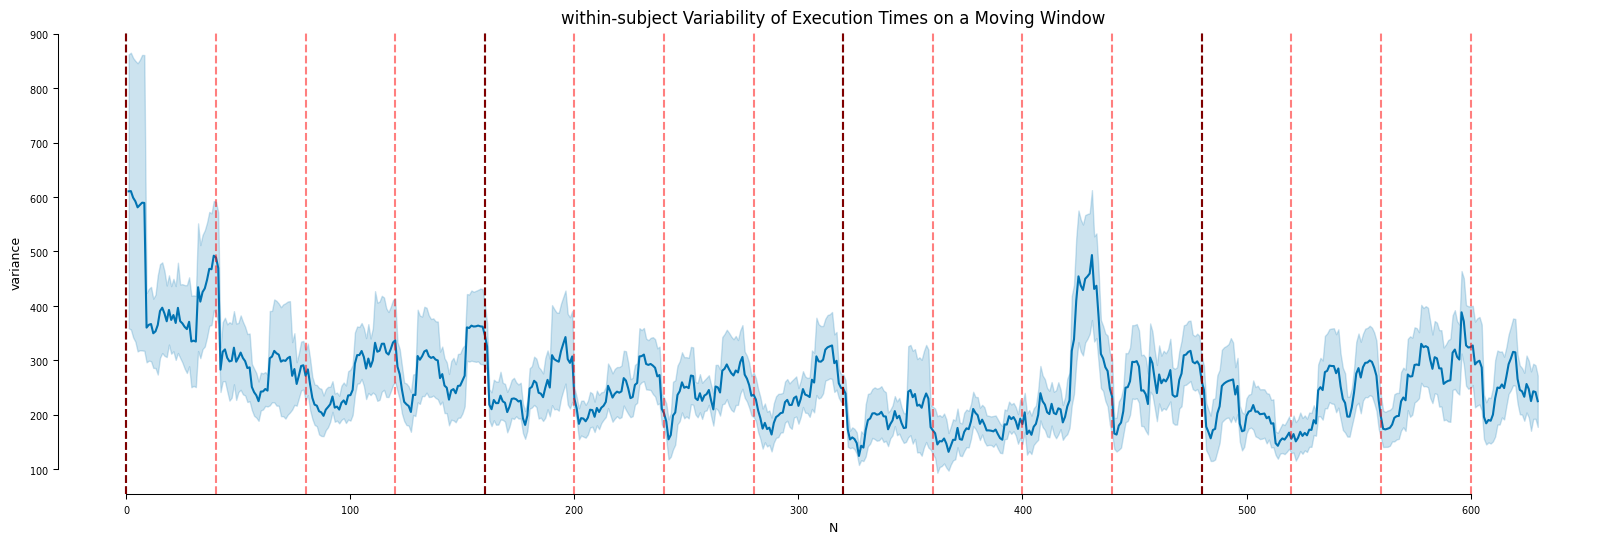

In [126]:
plt.figure(figsize=(20, 6))
# distances = distances[distances['N'] > 100]
sns.lineplot(data=distances, x='N', y='variance', errorbar='se')

#plot day changes
day_changes = forces_wide[forces_wide['day_change'] == 1]
for n in day_changes['N'].unique():
    plt.axvline(n - 1, color='black', linestyle='--', alpha=1)


# plot block changes
block_changes = forces_wide[forces_wide['block_change'] == 1]
for n in block_changes['N'].unique():
    plt.axvline(n - 1, color='red', linestyle='--', alpha=0.5)


plt.title('within-subject Variability of Execution Times on a Moving Window')
sns.despine(trim=True)

In [244]:
# calculate variance of ETs on a moving window for each subject
window_size = 10
distances = []


for N, ndata in forces_wide.groupby('N'):
    var = np.std(ndata['ET'].values)

    distances.append({
        'variance': var,
        'N': N
    })

distances = pd.DataFrame(distances)

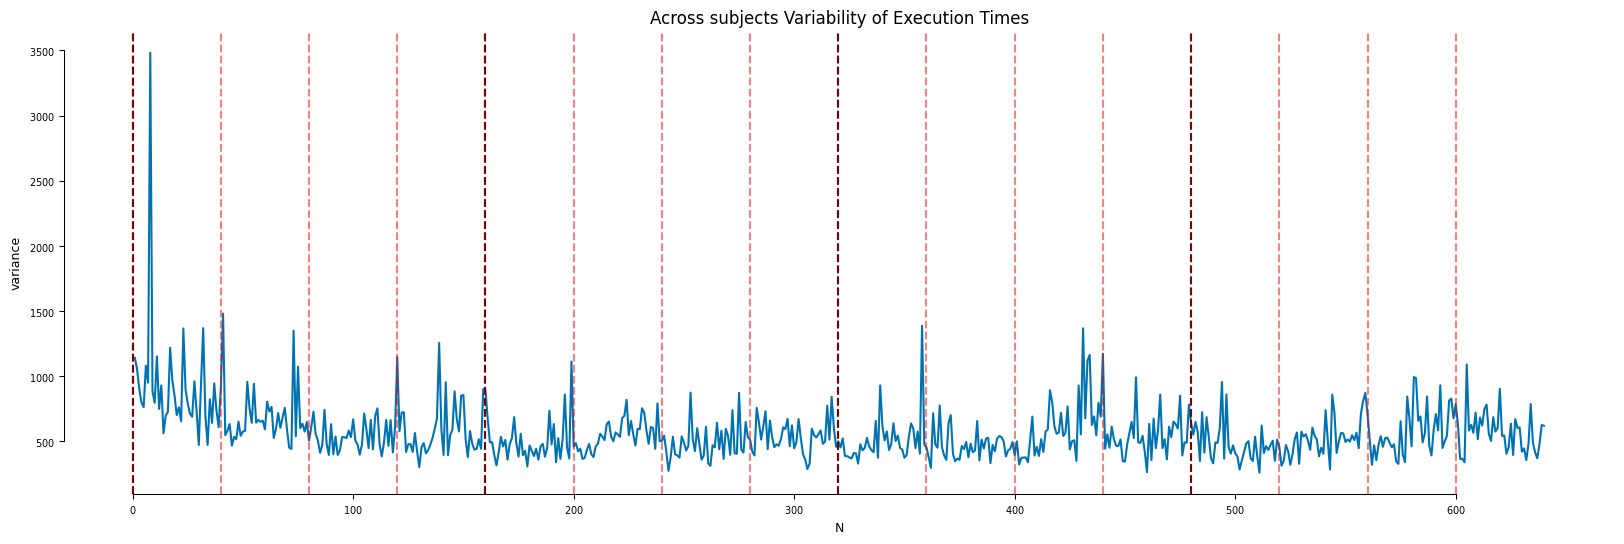

In [245]:
plt.figure(figsize=(20, 6))

sns.lineplot(data=distances, x='N', y='variance', errorbar='se')

#plot day changes
day_changes = forces_wide[forces_wide['day_change'] == 1]
for n in day_changes['N'].unique():
    plt.axvline(n - 1, color='black', linestyle='--', alpha=1)

# plot block changes
block_changes = forces_wide[forces_wide['block_change'] == 1]
for n in block_changes['N'].unique():
    plt.axvline(n - 1, color='red', linestyle='--', alpha=0.5)
    
plt.title('Across subjects Variability of Execution Times')
sns.despine(trim=True)


In [246]:
# calculate mean of ETs on a moving window for each subject
window_size = 20
means = []
for subind, subdata in forces_wide.groupby('SubNum'):
    for i in range(len(subdata) - window_size):
        window_data = subdata.iloc[i:i + window_size]
        # compute the variance of the ETs in the window
        mean = np.mean(window_data['ET'].values)
        mean = np.median(window_data['ET'].values)  # Use median to reduce the effect of outliers

        means.append({
            'SubNum': subind,
            'mean': mean,
            'N': window_data['N'].values[0]
        })

means = pd.DataFrame(means)

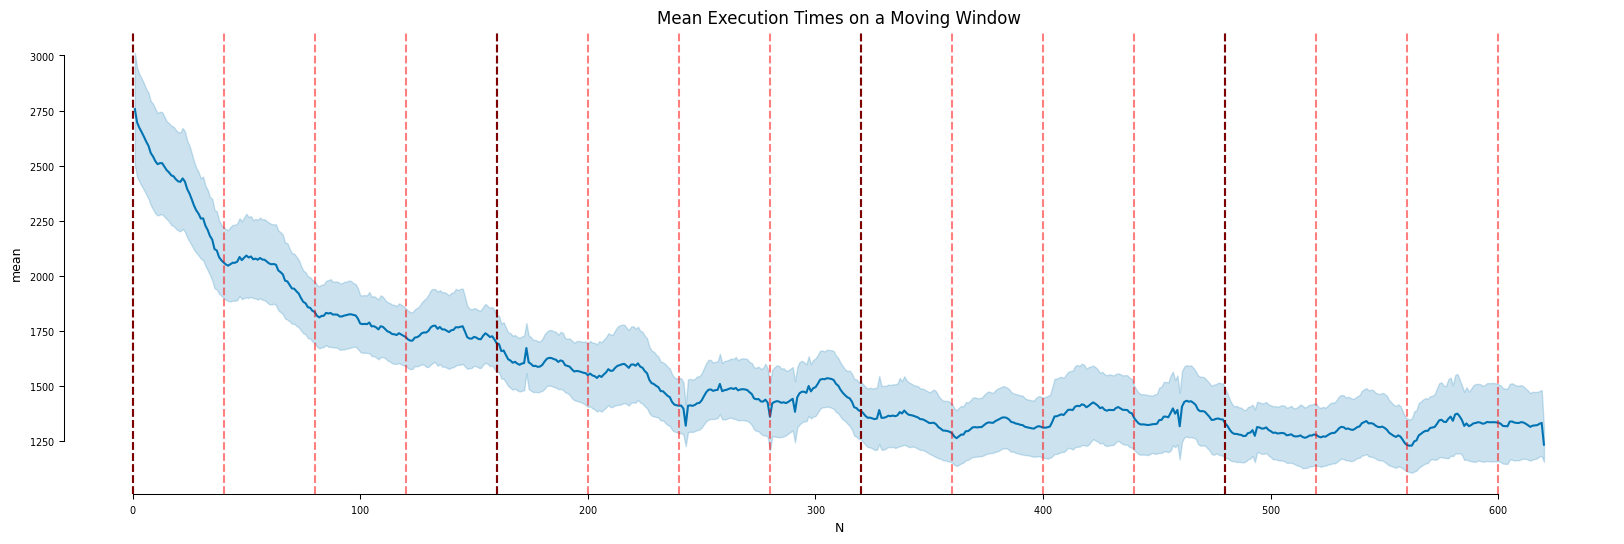

In [247]:
plt.figure(figsize=(20, 6))
sns.lineplot(data=means, x='N', y='mean', errorbar='se')

#plot day changes
day_changes = forces_wide[forces_wide['day_change'] == 1]
for n in day_changes['N'].unique():
    plt.axvline(n - 1, color='black', linestyle='--', alpha=1)


# plot block changes
block_changes = forces_wide[forces_wide['block_change'] == 1]
for n in block_changes['N'].unique():
    plt.axvline(n - 1, color='red', linestyle='--', alpha=0.5)


plt.title('Mean Execution Times on a Moving Window')
sns.despine(trim=True)

In [20]:
window_size = num_trials_per_block
force_ET_trend = []

for subind, subdata in forces_wide.groupby('SubNum'):
    # bin the data into windows of size window_size
    # for i in range(0, len(subdata) - window_size + 1, window_size):
    for bn, block_data in subdata.groupby('BN'):
        # print(i, i + window_size)

        # window_data = subdata.iloc[i:i + window_size]
        window_data = block_data

        window_data = window_data[window_data['points'] != -1]
        # print(len(window_data))

        force_vectors = np.array(window_data['force_vector'].tolist())
        # compute the mean of the force vectors in the window
        mean_force_vector = np.mean(force_vectors, axis=0)
        # compute the variance of the force vectors in the window
        var = np.sqrt(((force_vectors - mean_force_vector) ** 2).sum(axis = 1).mean())


        # compute the mean ET in the window
        mean_ET = np.mean(window_data['ET'].values)
        
        force_ET_trend.append({
            'SubNum': subind,
            'variance': var,
            'mean_ET': mean_ET,
            # 'bin': i // window_size + 1
            'bin': bn,
            'day': window_data['day'].values[0],
            'BN': window_data['BN'].values[0],
            'mean_force_length': np.linalg.norm(mean_force_vector),
            'var_force_length': np.std(np.linalg.norm(force_vectors, axis=1))
        })

force_ET_trend = pd.DataFrame(force_ET_trend)


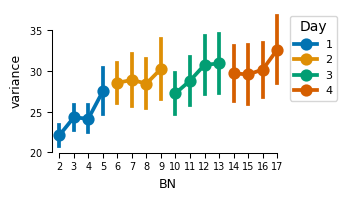

In [21]:
sns.pointplot(data=force_ET_trend, x='BN', y='variance', errorbar='se', hue = 'day', palette='colorblind')
plt.legend(title='Day', loc='upper left', bbox_to_anchor=(1, 1))
sns.despine(trim=True)
plt.savefig(path_figs + 'force_variability_across_days.pdf', dpi=300, bbox_inches='tight')

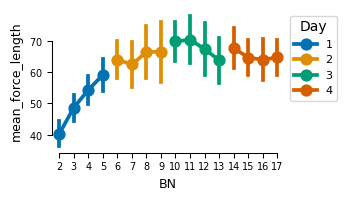

In [23]:
sns.pointplot(data=force_ET_trend, x='BN', y='mean_force_length', errorbar='se', hue = 'day', palette='colorblind')
plt.legend(title='Day', loc='upper left', bbox_to_anchor=(1, 1))
sns.despine(trim=True)
plt.savefig(path_figs + 'mean_force_length_across_days.pdf', dpi=300, bbox_inches='tight')

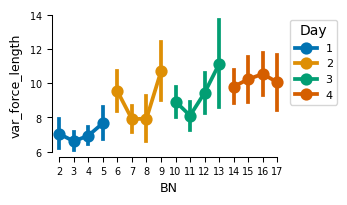

In [24]:
sns.pointplot(data=force_ET_trend, x='BN', y='var_force_length', errorbar='se', hue = 'day', palette='colorblind')
plt.legend(title='Day', loc='upper left', bbox_to_anchor=(1, 1))
sns.despine(trim=True)
plt.savefig(path_figs + 'var_force_length_across_days.pdf', dpi=300, bbox_inches='tight')

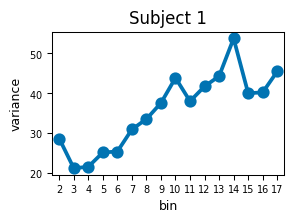

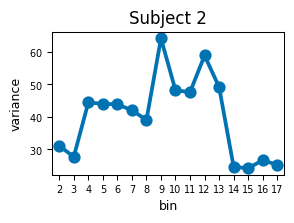

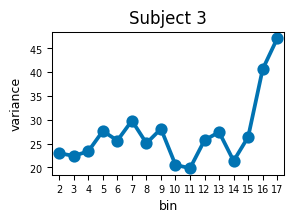

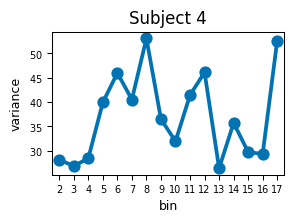

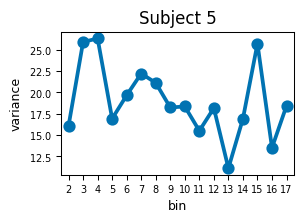

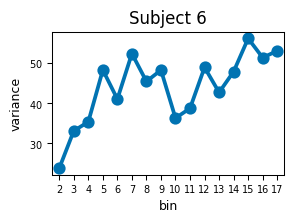

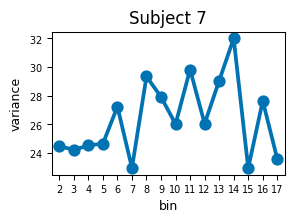

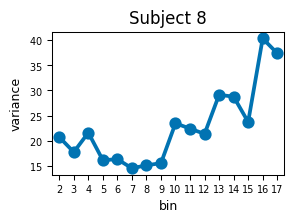

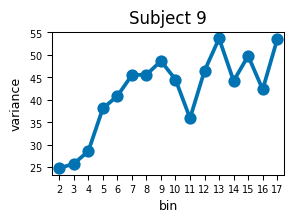

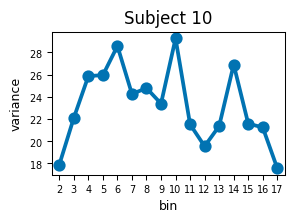

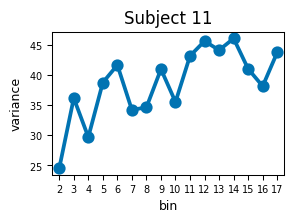

In [64]:
for subnum, subdata in force_ET_trend.groupby('SubNum'):
    plt.figure()
    sns.pointplot(data=subdata, x='bin', y='variance')
    plt.title(f'Subject {subnum}')

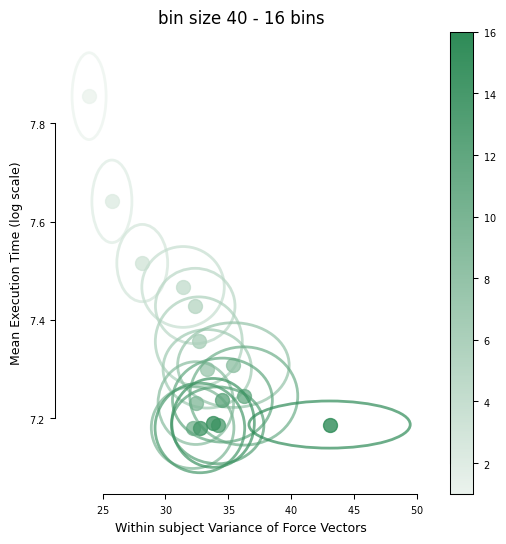

In [88]:
from matplotlib.patches import Ellipse

plt.figure(figsize=(6, 6))
n_bins = force_ET_trend['bin'].nunique()
norm = plt.Normalize(vmin=force_ET_trend['bin'].min(), vmax=force_ET_trend['bin'].max())
cmap = sns.light_palette("seagreen", as_cmap=True, n_colors = n_bins)
ax = plt.gca()

for i, (binnum, bin_data) in enumerate(force_ET_trend.groupby('bin')):
    mean_x = bin_data['variance'].mean()
    mean_y = np.log(bin_data['mean_ET']).mean()
    se_x = bin_data['variance'].std() / np.sqrt(len(bin_data))
    se_y = np.log(bin_data['mean_ET']).std() / np.sqrt(len(bin_data))

   # Plot the mean point
    ax.scatter(mean_x, mean_y, c=binnum, s=100, label=f'Bin {binnum}', alpha=0.8, cmap = cmap,
               norm = norm)
    
    
    # Draw the SE ellipse
    ellipse = Ellipse(
        (mean_x, mean_y),
        width=2*se_x,  # ±1 SE
        height=2*se_y,
        edgecolor=cmap(norm(binnum)),
        facecolor='none',
        lw=2,
        alpha=0.7
    )
    ax.add_patch(ellipse)


cbar = plt.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)


plt.xlabel('Within subject Variance of Force Vectors')
plt.ylabel('Mean Execution Time (log scale)')
plt.title(f"bin size {window_size} - {n_bins} bins")
# plt.legend(title='Bin', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(trim=True)

    

In [250]:
# window_size = 50
# force_ET_trend = []

# # bin the data into windows of size window_size
# for subind, subdata in forces_wide.groupby('SubNum'):
#     for i in range(0, len(subdata) - window_size + 1, window_size):
#         # print(i, i + window_size)
#         window_data = subdata.iloc[i:i + window_size]
#         force_vectors = np.array(window_data['force_vector'].tolist())
#         # compute the mean of the force vectors in the window
#         mean_force_vector = np.mean(force_vectors, axis=0)
#         # compute the mean ET in the window
#         mean_ET = np.mean(window_data['ET'].values)
        
#         force_ET_trend.append({
#             'SubNum': subind,
#             'mean_force': mean_force_vector,
#             'mean_ET': mean_ET,
#             'bin': i // window_size + 1
#         })

# force_ET_trend = pd.DataFrame(force_ET_trend)


In [251]:
# plt.figure(figsize=(6, 6))
# n_bins = force_ET_trend['bin'].nunique()
# norm = plt.Normalize(vmin=force_ET_trend['bin'].min(), vmax=force_ET_trend['bin'].max())
# cmap = sns.light_palette("seagreen", as_cmap=True, n_colors = n_bins)
# ax = plt.gca()
# for bin, bindata in force_ET_trend.groupby('bin'):
#     force_vectors = np.array(bindata['mean_force'].tolist())
#     mean_force = bindata['mean_force'].mean()
#     mean_y = np.log(bindata['mean_ET']).mean()

#     variation_force = np.sqrt(((force_vectors - mean_force) ** 2).sum(axis=1).mean())
#     se_y = np.log(bindata['mean_ET']).std() / np.sqrt(len(bindata))

#     # Plot the mean point
#     ax.scatter(variation_force, mean_y, c=bin, s=100, label=f'Bin {bin}', alpha=0.8, cmap = cmap,
#                norm = norm)
    
#     # sns.scatterplot(x=[variation_force], y=[mean_y], color=cmap(norm(bin)), s=100, edgecolor='black', alpha=0.8,
#     #                 )

#     # add error bars
#     ax.errorbar(variation_force, mean_y, yerr=se_y, fmt='o', color=cmap(norm(bin)), alpha=0.5,
#                 capsize=5, elinewidth=2, markeredgewidth=2)
    


# cbar = plt.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)
# plt.xlabel('Across subject Variance of Force Vectors')
# plt.ylabel('Mean Execution Time (log scale)')

# sns.despine(trim=True)
    

    

# Breaking down variability into IPI variability, peak force variability 

In [94]:
window_size = num_trials_per_block
force_ET_trend = []
RT_offset = 0.1

for subind, subdata in subjs.groupby('SubNum'):
    # bin the data into windows of size window_size
    # for i in range(0, len(subdata) - window_size + 1, window_size):
    for bn, block_data in subdata.groupby('BN'):
        # print(i, i + window_size)

        # window_data = subdata.iloc[i:i + window_size]
        window_data = block_data

        window_data = window_data[window_data['points'] != -1]
        # print(len(window_data))

        # compute a mapping of press times in the warped space
        press_times = []
        for _, trialdata in window_data.iterrows():
            norm_press_times = np.array([trialdata[f'IPI{i}'] for i in range(1, seq_length)])
            norm_press_times = norm_press_times / trialdata['MT']
            norm_press_times = np.cumsum(norm_press_times)
            norm_press_times = norm_press_times + RT_offset
            press_times.append(norm_press_times)

        press_times = np.array(press_times)
        # compute the mean of the press times in the window
        mean_press_times = np.mean(press_times, axis=0)
        # compute the variance of the press times in the window
        var = np.sqrt(((press_times - mean_press_times) ** 2).sum(axis=1).mean())

        # compute the mean ET in the window
        mean_ET = np.mean(window_data['ET'].values)
        
        force_ET_trend.append({
            'SubNum': subind,
            'variance': var,
            'mean_ET': mean_ET,
            'bin': i // window_size + 1,
            'BN': window_data['BN'].values[0],
            'day': window_data['day'].values[0]
        })

force_ET_trend = pd.DataFrame(force_ET_trend)


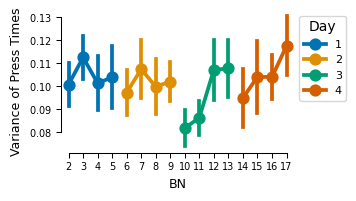

In [95]:
sns.pointplot(data=force_ET_trend, x='BN', y='variance', errorbar='se', hue = 'day', palette='colorblind')
plt.legend(title='Day', loc='upper left', bbox_to_anchor=(1, 1))
plt.ylabel('Variance of Press Times')
sns.despine(trim=True)
plt.savefig(path_figs + 'press_time_variability_across_days.pdf', dpi=300, bbox_inches='tight')


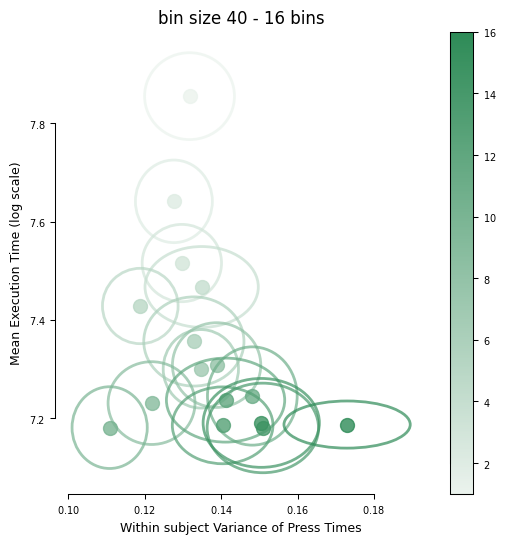

In [92]:
from matplotlib.patches import Ellipse

plt.figure(figsize=(6, 6))
n_bins = force_ET_trend['bin'].nunique()
norm = plt.Normalize(vmin=force_ET_trend['bin'].min(), vmax=force_ET_trend['bin'].max())
cmap = sns.light_palette("seagreen", as_cmap=True, n_colors = n_bins)
ax = plt.gca()

for i, (binnum, bin_data) in enumerate(force_ET_trend.groupby('bin')):
    mean_x = bin_data['variance'].mean()
    mean_y = np.log(bin_data['mean_ET']).mean()
    se_x = bin_data['variance'].std() / np.sqrt(len(bin_data))
    se_y = np.log(bin_data['mean_ET']).std() / np.sqrt(len(bin_data))

   # Plot the mean point
    ax.scatter(mean_x, mean_y, c=binnum, s=100, label=f'Bin {binnum}', alpha=0.8, cmap = cmap,
               norm = norm)
    
    
    # Draw the SE ellipse
    ellipse = Ellipse(
        (mean_x, mean_y),
        width=2*se_x,  # ±1 SE
        height=2*se_y,
        edgecolor=cmap(norm(binnum)),
        facecolor='none',
        lw=2,
        alpha=0.7
    )
    ax.add_patch(ellipse)


cbar = plt.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)


plt.xlabel('Within subject Variance of Press Times')
plt.ylabel('Mean Execution Time (log scale)')
plt.title(f"bin size {window_size} - {n_bins} bins")
# plt.legend(title='Bin', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(trim=True)

    

In [254]:
window_size = num_trials_per_block
force_ET_trend = []
RT_offset = 0.1

for subind, subdata in subjs.groupby('SubNum'):
    # bin the data into windows of size window_size
    for i in range(0, len(subdata) - window_size + 1, window_size):
        # print(i, i + window_size)

        window_data = subdata.iloc[i:i + window_size]

        # window_data = window_data[window_data['points'] != -1]
        # print(len(window_data))
        
        press_times = window_data[[f'IPI{i}' for i in range(1, seq_length)]].cumsum(axis=1)

        # compute average correlation of press times in the window
        corrs = press_times.T.corr()
        # extract the upper triangle of the correlation matrix
        upper_idx = np.triu_indices(corrs.shape[0], k=1)
        mean_corr = corrs.values[upper_idx].mean()
    
        # compute the mean ET in the window
        mean_ET = np.mean(window_data['ET'].values)
        
        force_ET_trend.append({
            'SubNum': subind,
            'variance': mean_corr,
            'mean_ET': mean_ET,
            'bin': i // window_size + 1
        })

force_ET_trend = pd.DataFrame(force_ET_trend)


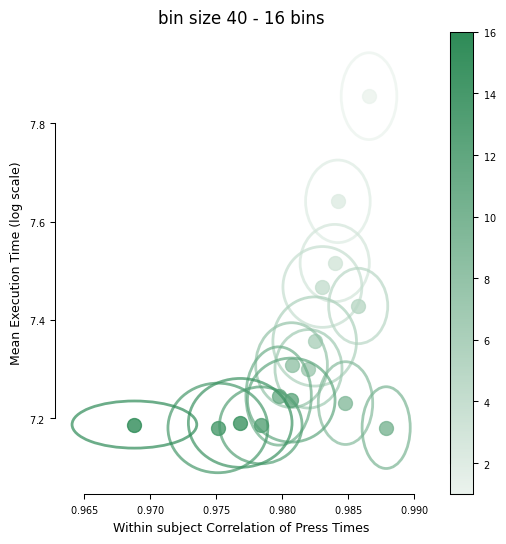

In [255]:
from matplotlib.patches import Ellipse

plt.figure(figsize=(6, 6))
n_bins = force_ET_trend['bin'].nunique()
norm = plt.Normalize(vmin=force_ET_trend['bin'].min(), vmax=force_ET_trend['bin'].max())
cmap = sns.light_palette("seagreen", as_cmap=True, n_colors = n_bins)
ax = plt.gca()

for i, (binnum, bin_data) in enumerate(force_ET_trend.groupby('bin')):
    mean_x = bin_data['variance'].mean()
    mean_y = np.log(bin_data['mean_ET']).mean()
    se_x = bin_data['variance'].std() / np.sqrt(len(bin_data))
    se_y = np.log(bin_data['mean_ET']).std() / np.sqrt(len(bin_data))

   # Plot the mean point
    ax.scatter(mean_x, mean_y, c=binnum, s=100, label=f'Bin {binnum}', alpha=0.8, cmap = cmap,
               norm = norm)
    
    
    # Draw the SE ellipse
    ellipse = Ellipse(
        (mean_x, mean_y),
        width=2*se_x,  # ±1 SE
        height=2*se_y,
        edgecolor=cmap(norm(binnum)),
        facecolor='none',
        lw=2,
        alpha=0.7
    )
    ax.add_patch(ellipse)


cbar = plt.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)


plt.xlabel('Within subject Correlation of Press Times')
plt.ylabel('Mean Execution Time (log scale)')
plt.title(f"bin size {window_size} - {n_bins} bins")
# plt.legend(title='Bin', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(trim=True)

    

In [256]:
window_size = num_trials_per_block
force_ET_trend = []
RT_offset = 0.1

for subind, subdata in subjs.groupby('SubNum'):
    # bin the data into windows of size window_size
    for i in range(0, len(subdata) - window_size + 1, window_size):
        # print(i, i + window_size)

        window_data = subdata.iloc[i:i + window_size]

        # window_data = window_data[window_data['points'] != -1]
        # print(len(window_data))
        
        press_times = window_data[[f'IPI{i}' for i in range(1, seq_length)]]

        # compute average correlation of press times in the window
        corrs = press_times.T.corr()
        # extract the upper triangle of the correlation matrix
        upper_idx = np.triu_indices(corrs.shape[0], k=1)
        mean_corr = corrs.values[upper_idx].mean()
    
        # compute the mean ET in the window
        mean_ET = np.mean(window_data['ET'].values)
        
        force_ET_trend.append({
            'SubNum': subind,
            'variance': mean_corr,
            'mean_ET': mean_ET,
            'bin': i // window_size + 1
        })

force_ET_trend = pd.DataFrame(force_ET_trend)


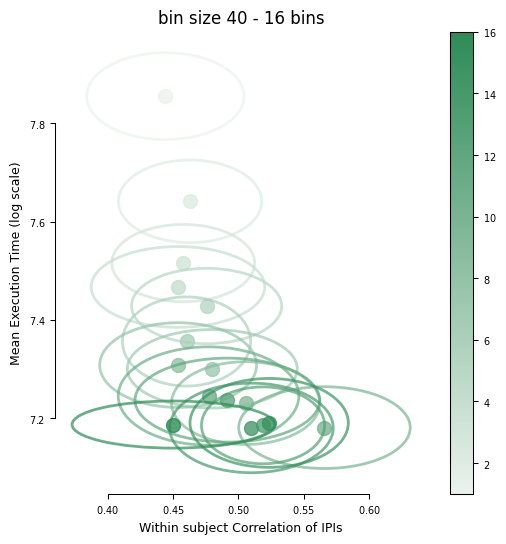

In [257]:
from matplotlib.patches import Ellipse

plt.figure(figsize=(6, 6))
n_bins = force_ET_trend['bin'].nunique()
norm = plt.Normalize(vmin=force_ET_trend['bin'].min(), vmax=force_ET_trend['bin'].max())
cmap = sns.light_palette("seagreen", as_cmap=True, n_colors = n_bins)
ax = plt.gca()

for i, (binnum, bin_data) in enumerate(force_ET_trend.groupby('bin')):
    mean_x = bin_data['variance'].mean()
    mean_y = np.log(bin_data['mean_ET']).mean()
    se_x = bin_data['variance'].std() / np.sqrt(len(bin_data))
    se_y = np.log(bin_data['mean_ET']).std() / np.sqrt(len(bin_data))

   # Plot the mean point
    ax.scatter(mean_x, mean_y, c=binnum, s=100, label=f'Bin {binnum}', alpha=0.8, cmap = cmap,
               norm = norm)
    
    
    # Draw the SE ellipse
    ellipse = Ellipse(
        (mean_x, mean_y),
        width=2*se_x,  # ±1 SE
        height=2*se_y,
        edgecolor=cmap(norm(binnum)),
        facecolor='none',
        lw=2,
        alpha=0.7
    )
    ax.add_patch(ellipse)


cbar = plt.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)


plt.xlabel('Within subject Correlation of IPIs')
plt.ylabel('Mean Execution Time (log scale)')
plt.title(f"bin size {window_size} - {n_bins} bins")
# plt.legend(title='Bin', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(trim=True)

    

In [ ]:
# for each finger press, calculate it's press time (passing 1.5 N) and depress time (passing 0.8 N on the way down)
# then calculate the peak force between the press time and depress time
press_threshold = 1.5
depress_threshold = 0.8
peak_forces = []
for subind, subdata in tqdm(subjs_forces.groupby('SubNum')):
    for bn, block_data in subdata.groupby('BN'):
        for tn, trial_data in block_data.groupby('TN'):
            trial_data = trial_data.sort_values(by='time')
            press_time = None
            depress_time = None
            peak_force = None
            for finger in range(1, 6):
                finger_data = trial_data[trial_data['Force_Number'] == f'force{finger}R']
                while True:
                    # find press times (crossing 1.5 N)
                    pressed = finger_data[finger_data['Force_Value'] >= press_threshold]
                    if pressed.empty:
                        break
                    press_time = pressed['time'].values[0]
                    # find depress times (crossing 0.8 N after press time)
                    depressed = finger_data[(finger_data['Force_Value'] <= depress_threshold) & (finger_data['time'] > press_time)]
                    if depressed.empty:
                        depress_time = finger_data['time'].values[-1]
                    else:
                        depress_time = depressed['time'].values[0]
                    # find peak force between press time and depress time
                    peak_force = finger_data[(finger_data['time'] >= press_time) & (finger_data['time'] <= depress_time)]['Force_Value'].max()
                    # remove the processed data
                    finger_data = finger_data[finger_data['time'] > depress_time]
                    peak_forces.append({
                        'SubNum': subind,
                        'BN': bn,
                        'TN': tn,
                        'Finger': finger,
                        'Press_Time': press_time,
                        'Depress_Time': depress_time,
                        'Peak_Force': peak_force,
                        'points': trial_data['points'].values[0],
                    })

peak_forces = pd.DataFrame(peak_forces)
                
# check the number of rows per trial
peak_forces.groupby(['SubNum', 'BN', 'TN']).size().value_counts()

# drop rows with not seq length peaks
peak_forces = peak_forces.groupby(['SubNum', 'BN', 'TN']).filter(lambda x : len(x) == seq_length)

100%|██████████| 11/11 [00:45<00:00,  4.16s/it]


In [8]:
#adding day column 
peak_forces['day'] = 0
peak_forces.loc[peak_forces['BN'].isin(day1_blocks), 'day'] = 1
peak_forces.loc[peak_forces['BN'].isin(day2_blocks), 'day'] = 2
peak_forces.loc[peak_forces['BN'].isin(day3_blocks), 'day'] = 3
peak_forces.loc[peak_forces['BN'].isin(day4_blocks), 'day'] = 4

# adding a column specifying the press order based on the press time
peak_forces = peak_forces.sort_values(by=['SubNum', 'BN', 'TN', 'Press_Time'])
peak_forces['Press_Order'] = peak_forces.groupby(['SubNum', 'BN', 'TN']).cumcount() + 1
peak_forces = peak_forces.pivot_table(index=['SubNum', 'BN', 'TN', 'points', 'day'], columns='Press_Order', values='Peak_Force').reset_index()
peak_forces.columns = ['SubNum', 'BN', 'TN', 'points', 'day'] + [f'Peak_Force_{i}' for i in range(1, seq_length + 1)]

# adding a column having list of peak forces 
peak_forces['peak_force_vector'] = peak_forces[[f'Peak_Force_{i}' for i in range(1, seq_length + 1)]].apply(lambda x: np.array(x), axis=1)


In [12]:
window_size = num_trials_per_block
force_ET_trend = []

for subind, subdata in peak_forces.groupby('SubNum'):
    for bn, bn_data in subdata.groupby('BN'):
        bn_data = bn_data[bn_data['points'] != -1]
        # print(len(bn_data))
        peak_force_vectors = np.array(bn_data['peak_force_vector'].tolist())
        # compute the mean of the peak force vectors in the block
        mean_peak_force_vector = np.mean(peak_force_vectors, axis=0)
        # compute the variance of the peak force vectors in the block
        var = np.sqrt(((peak_force_vectors - mean_peak_force_vector) ** 2).sum(axis = 1).mean())

        # compute the variance of length of force vectors in the block
        force_lengths = np.linalg.norm(peak_force_vectors, axis=1)
        var_length = np.std(force_lengths)

        # compute the mean ET in the block
        mean_ET = np.mean(subjs[(subjs['SubNum'] == subind) & (subjs['BN'] == bn)]['ET'].values)
        
        force_ET_trend.append({
            'SubNum': subind,
            'variance': var,
            'variance_length': var_length,
            'mean_ET': mean_ET,
            'mean_force_length': np.linalg.norm(mean_peak_force_vector),
            'bin': bn,
            'day': bn_data['day'].values[0],
            'BN': bn
        })
        
force_ET_trend = pd.DataFrame(force_ET_trend)


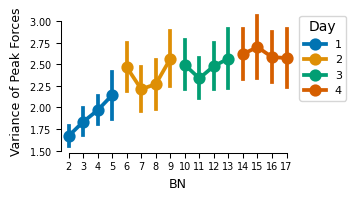

In [15]:
sns.pointplot(data=force_ET_trend, x='BN', y='variance', errorbar='se', hue = 'day', palette='colorblind')
plt.legend(title='Day', loc='upper left', bbox_to_anchor=(1, 1))
plt.ylabel('Variance of Peak Forces')
sns.despine(trim=True)
# plt.savefig(path_figs + 'peak_force_variability_across_days.pdf', dpi=300, bbox_inches='tight')

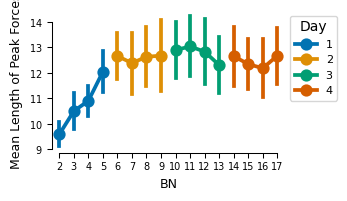

In [11]:
sns.pointplot(data=force_ET_trend, x = 'BN', y='mean_force_length', errorbar='se', hue = 'day', palette='colorblind')
plt.legend(title='Day', loc='upper left', bbox_to_anchor=(1, 1))
plt.ylabel('Mean Length of Peak Forces')
sns.despine(trim=True)
plt.savefig(path_figs + 'mean_peak_force_length_across_days.pdf', dpi=300, bbox_inches='tight')

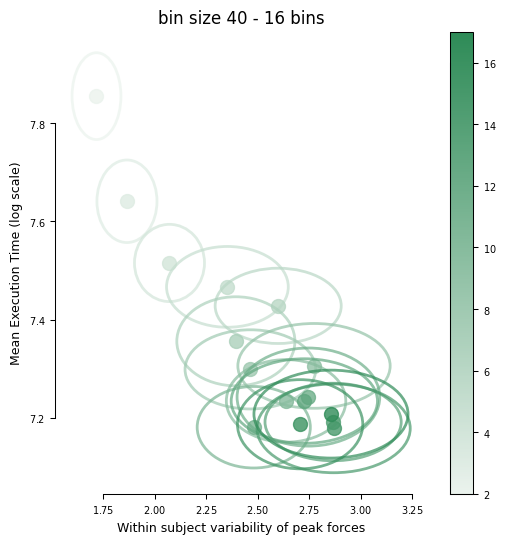

In [26]:
from matplotlib.patches import Ellipse

plt.figure(figsize=(6, 6))
n_bins = force_ET_trend['bin'].nunique()
norm = plt.Normalize(vmin=force_ET_trend['bin'].min(), vmax=force_ET_trend['bin'].max())
cmap = sns.light_palette("seagreen", as_cmap=True, n_colors = n_bins)
ax = plt.gca()

for i, (binnum, bin_data) in enumerate(force_ET_trend.groupby('bin')):
    mean_x = bin_data['variance'].mean()
    mean_y = np.log(bin_data['mean_ET']).mean()
    se_x = bin_data['variance'].std() / np.sqrt(len(bin_data))
    se_y = np.log(bin_data['mean_ET']).std() / np.sqrt(len(bin_data))

   # Plot the mean point
    ax.scatter(mean_x, mean_y, c=binnum, s=100, label=f'Bin {binnum}', alpha=0.8, cmap = cmap,
               norm = norm)
    
    
    # Draw the SE ellipse
    ellipse = Ellipse(
        (mean_x, mean_y),
        width=2*se_x,  # ±1 SE
        height=2*se_y,
        edgecolor=cmap(norm(binnum)),
        facecolor='none',
        lw=2,
        alpha=0.7
    )
    ax.add_patch(ellipse)


cbar = plt.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)


plt.xlabel('Within subject variability of peak forces')
plt.ylabel('Mean Execution Time (log scale)')
plt.title(f"bin size {window_size} - {n_bins} bins")
# plt.legend(title='Bin', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(trim=True)

    

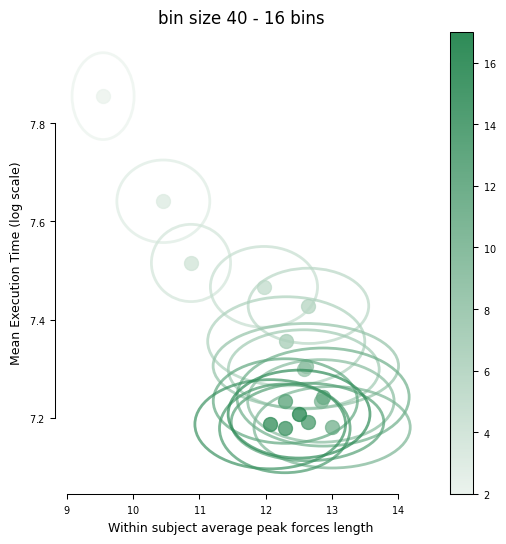

In [27]:
from matplotlib.patches import Ellipse

plt.figure(figsize=(6, 6))
n_bins = force_ET_trend['bin'].nunique()
norm = plt.Normalize(vmin=force_ET_trend['bin'].min(), vmax=force_ET_trend['bin'].max())
cmap = sns.light_palette("seagreen", as_cmap=True, n_colors = n_bins)
ax = plt.gca()

for i, (binnum, bin_data) in enumerate(force_ET_trend.groupby('bin')):
    mean_x = bin_data['mean_force_length'].mean()
    mean_y = np.log(bin_data['mean_ET']).mean()
    se_x = bin_data['mean_force_length'].std() / np.sqrt(len(bin_data))
    se_y = np.log(bin_data['mean_ET']).std() / np.sqrt(len(bin_data))

   # Plot the mean point
    ax.scatter(mean_x, mean_y, c=binnum, s=100, label=f'Bin {binnum}', alpha=0.8, cmap = cmap,
               norm = norm)
    
    
    # Draw the SE ellipse
    ellipse = Ellipse(
        (mean_x, mean_y),
        width=2*se_x,  # ±1 SE
        height=2*se_y,
        edgecolor=cmap(norm(binnum)),
        facecolor='none',
        lw=2,
        alpha=0.7
    )
    ax.add_patch(ellipse)


cbar = plt.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)


plt.xlabel('Within subject average peak forces length')
plt.ylabel('Mean Execution Time (log scale)')
plt.title(f"bin size {window_size} - {n_bins} bins")
# plt.legend(title='Bin', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(trim=True)

    

In [28]:
window_size = num_trials_per_block
force_ET_trend = []

for subind, subdata in forces_wide.groupby('SubNum'):
    for bn, bn_data in subdata.groupby('BN'):
        # compute mean length of the force vectors in the block
        force_vectors = np.array(bn_data['force_vector'].tolist())
        force_lengths = np.linalg.norm(force_vectors, axis=1)
        mean_peak_force_vector = np.mean(force_vectors, axis=0)
        # compute the mean ET in the block
        mean_ET = np.mean(subjs[(subjs['SubNum'] == subind) & (subjs['BN'] == bn)]['ET'].values)
        
        force_ET_trend.append({
            'SubNum': subind,
            'mean_ET': mean_ET,
            'mean_force_length': np.mean(force_lengths),
            'bin': bn
        })

force_ET_trend = pd.DataFrame(force_ET_trend)


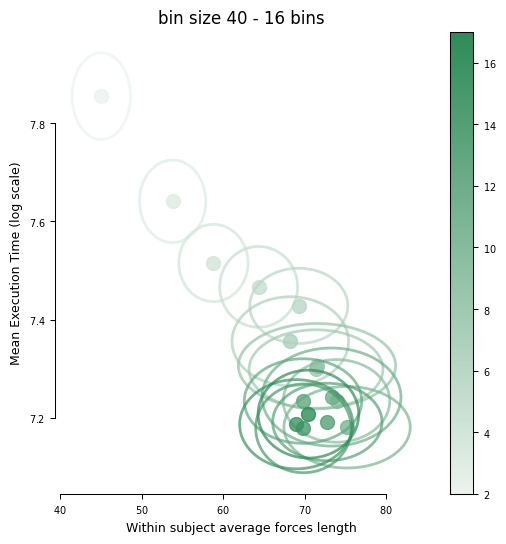

In [30]:
from matplotlib.patches import Ellipse

plt.figure(figsize=(6, 6))
n_bins = force_ET_trend['bin'].nunique()
norm = plt.Normalize(vmin=force_ET_trend['bin'].min(), vmax=force_ET_trend['bin'].max())
cmap = sns.light_palette("seagreen", as_cmap=True, n_colors = n_bins)
ax = plt.gca()

for i, (binnum, bin_data) in enumerate(force_ET_trend.groupby('bin')):
    mean_x = bin_data['mean_force_length'].mean()
    mean_y = np.log(bin_data['mean_ET']).mean()
    se_x = bin_data['mean_force_length'].std() / np.sqrt(len(bin_data))
    se_y = np.log(bin_data['mean_ET']).std() / np.sqrt(len(bin_data))

   # Plot the mean point
    ax.scatter(mean_x, mean_y, c=binnum, s=100, label=f'Bin {binnum}', alpha=0.8, cmap = cmap,
               norm = norm)
    
    
    # Draw the SE ellipse
    ellipse = Ellipse(
        (mean_x, mean_y),
        width=2*se_x,  # ±1 SE
        height=2*se_y,
        edgecolor=cmap(norm(binnum)),
        facecolor='none',
        lw=2,
        alpha=0.7
    )
    ax.add_patch(ellipse)


cbar = plt.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)


plt.xlabel('Within subject average forces length')
plt.ylabel('Mean Execution Time (log scale)')
plt.title(f"bin size {window_size} - {n_bins} bins")
# plt.legend(title='Bin', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(trim=True)

    